In [1]:
import xarray as xr
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature  
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
import dask.array as da

LOAD IN SITU AND GLORYS

In [2]:
out_path = '../data_for_lstm/var_depths_data_for_LSTM_B2_wgm.nc'

In [3]:
ds_insitu = xr.open_dataset('../data_for_lstm/var_depths_data_for_LSTM_B1_wg.nc',
                            decode_times=True)
ds_insitu

<xarray.Dataset> Size: 1GB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/21)
    LATITUDE           (profile) float64 1MB ...
    LONGITUDE          (profile) float64 1MB ...
    TIME               (profile) datetime64[ns] 1MB ...
    TEMP               (profile, depth) float64 150MB ...
    PSAL               (profile, depth) float64 150MB ...
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    SSS_glorys         (profile) float64 1MB ...
    ADT                (profile) float64 1MB ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
    S_glorys           (profile, depth) float64 150MB ...
    T_glorys           (profile, depth) float64 150MB ...
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [4]:
GLORYS_DIR = '/media/nicolas/DATOS/Reanalysis/GLORYS_monthly_2010_2022/data/'

# Build a dict: Period('YYYY-MM') -> filepath, parsed from filename pattern
# e.g. mercatorglorys12v1_gl12_mean_201001_NH.nc -> 2010-01
import re
glorys_file_map = {}
for fpath in sorted(glob.glob(GLORYS_DIR + '*.nc')):
    fname = os.path.basename(fpath)
    m = re.search(r'_(\d{4})(\d{2})_', fname)
    if m:
        ym_key = pd.Period(f'{m.group(1)}-{m.group(2)}', freq='M')
        glorys_file_map[ym_key] = fpath

print(f"Found {len(glorys_file_map)} monthly GLORYS files")
print("First few:", list(glorys_file_map.items())[:3])


Found 156 monthly GLORYS files
First few: [(Period('2010-01', 'M'), '/media/nicolas/DATOS/Reanalysis/GLORYS_monthly_2010_2022/data/mercatorglorys12v1_gl12_mean_201001_NH.nc'), (Period('2010-02', 'M'), '/media/nicolas/DATOS/Reanalysis/GLORYS_monthly_2010_2022/data/mercatorglorys12v1_gl12_mean_201002_NH.nc'), (Period('2010-03', 'M'), '/media/nicolas/DATOS/Reanalysis/GLORYS_monthly_2010_2022/data/mercatorglorys12v1_gl12_mean_201003_NH.nc')]


EXTRACT GLORYS PROFILES (month by month, with 5x5 window fallback)

In [5]:
def interp_to_insitu_depths(glorys_vals, glorys_depths, insitu_depths):
    """
    Interpolate one GLORYS profile from its native levels to insitu_depths.
    - Filters NaN levels first
    - Linear interpolation within the valid GLORYS depth range (np.interp)
    - Linear extrapolation at the surface (upward only, using first two valid levels)
    - NaN where insitu depth exceeds the deepest valid GLORYS level (no deep extrapolation)
    """
    valid = ~np.isnan(glorys_vals)
    if valid.sum() < 2:
        return np.full(len(insitu_depths), np.nan)
    gd = glorys_depths[valid]
    gv = glorys_vals[valid]

    result = np.interp(insitu_depths, gd, gv, left=np.nan, right=np.nan)

    # Surface-only linear extrapolation using first two valid GLORYS levels
    surface_mask = insitu_depths < gd[0]
    if np.any(surface_mask):
        slope = (gv[1] - gv[0]) / (gd[1] - gd[0])
        result[surface_mask] = gv[0] + slope * (insitu_depths[surface_mask] - gd[0])

    return result


# 5x5 spatial window offsets sorted by distance from centre (same as JN_B1)
OFFSETS_5X5 = [
    (1, 0), (-1, 0), (0, 1), (0, -1),
    (1, 1), (1, -1), (-1, 1), (-1, -1),
    (2, 0), (-2, 0), (0, 2), (0, -2),
    (2, 1), (2, -1), (-2, 1), (-2, -1), (1, 2), (1, -2), (-1, 2), (-1, -2),
    (2, 2), (2, -2), (-2, 2), (-2, -2)
]

def get_glorys_column_with_window(data_np, lat_grid, lon_grid, lat_val, lon_val):
    """
    Extract a depth column from data_np (depth, lat, lon) at the nearest grid point.
    If that point is all-NaN (land/ice), search within the 5x5 window.
    Longitude wraps around (global grid). Returns all-NaN if nothing found.
    """
    i_lat = int(np.argmin(np.abs(lat_grid - lat_val)))
    i_lon = int(np.argmin(np.abs(lon_grid - lon_val)))
    n_lat, n_lon = len(lat_grid), len(lon_grid)

    col = data_np[:, i_lat, i_lon]
    if not np.all(np.isnan(col)):
        return col

    for d_lat, d_lon in OFFSETS_5X5:
        ni_lat = i_lat + d_lat
        ni_lon = (i_lon + d_lon) % n_lon   # wrap longitude globally
        if 0 <= ni_lat < n_lat:
            col = data_np[:, ni_lat, ni_lon]
            if not np.all(np.isnan(col)):
                return col

    return np.full(data_np.shape[0], np.nan)


In [7]:
import gc
from tqdm.notebook import tqdm
import warnings

# Pre-allocate output arrays
n_profiles = len(ds_insitu['profile'])
insitu_depths = ds_insitu['depth'].values
n_insitu_depths = len(insitu_depths)

nearest_S_np = np.full((n_profiles, n_insitu_depths), np.nan)
nearest_T_np = np.full((n_profiles, n_insitu_depths), np.nan)

# Group in-situ profile indices by year-month
times_pd = pd.DatetimeIndex(ds_insitu['TIME'].values)
insitu_yearmonths = times_pd.to_period('M')
unique_yearmonths = sorted(set(insitu_yearmonths))

# Get grid info and depths from the first available file (reference only)
_ref_file = next(iter(glorys_file_map.values()))
with xr.open_dataset(_ref_file) as _ds_ref:
    glorys_depths = _ds_ref['depth'].values
    lat_grid = _ds_ref['latitude'].values
    lon_grid = _ds_ref['longitude'].values

missing_glorys_months = []
n_allnan_total = 0

for ym in tqdm(unique_yearmonths, desc='GLORYS months'):
    prof_indices = np.where(insitu_yearmonths == ym)[0]

    if ym not in glorys_file_map:
        warnings.warn(f"No GLORYS file for {ym}: {len(prof_indices)} profiles will remain NaN")
        missing_glorys_months.append(ym)
        continue

    # Open only the single file for this month — load into memory, then close
    # Use isel(time=0) to drop the time dimension and get (depth, lat, lon)
    with xr.open_dataset(glorys_file_map[ym]) as ds_month:
        so_np     = ds_month['so'].isel(time=0).values      # (depth, lat, lon)
        thetao_np = ds_month['thetao'].isel(time=0).values

    lats_vals = ds_insitu['LATITUDE'].values[prof_indices]
    lons_vals  = ds_insitu['LONGITUDE'].values[prof_indices]

    n_allnan_month = 0
    for j, prof_i in enumerate(prof_indices):
        S_col = get_glorys_column_with_window(so_np, lat_grid, lon_grid, lats_vals[j], lons_vals[j])
        T_col = get_glorys_column_with_window(thetao_np, lat_grid, lon_grid, lats_vals[j], lons_vals[j])

        nearest_S_np[prof_i] = interp_to_insitu_depths(S_col, glorys_depths, insitu_depths)
        nearest_T_np[prof_i] = interp_to_insitu_depths(T_col, glorys_depths, insitu_depths)

        if np.all(np.isnan(nearest_S_np[prof_i])):
            n_allnan_month += 1

    n_allnan_total += n_allnan_month

    # Free the monthly arrays before loading the next file
    del so_np, thetao_np
    gc.collect()

print(f"\nDone!")
print(f"  Months with no GLORYS file: {len(missing_glorys_months)}")
if missing_glorys_months:
    print(f"  Missing months: {missing_glorys_months[:5]}{'...' if len(missing_glorys_months) > 5 else ''}")
print(f"  Total all-NaN GLORYS columns (across all months): {n_allnan_total}")


GLORYS months:   0%|          | 0/132 [00:00<?, ?it/s]


Done!
  Months with no GLORYS file: 0
  Total all-NaN GLORYS columns (across all months): 0


--------------------------------
--------------------------------

Add S_glorys_filled and T_glorys_filled to the insitu dataset

In [8]:
np.isnan(nearest_S_np).sum(), np.isnan(nearest_T_np).sum()

(np.int64(9073682), np.int64(9073682))

In [9]:
ds_insitu['S_glorys_monthly'] = (('profile', 'depth'), nearest_S_np)
ds_insitu['S_glorys_monthly'].attrs['units'] = '1'
ds_insitu['S_glorys_monthly'].attrs['long_name'] = 'Practical salinity from GLORYS monthly reanalysis'
ds_insitu['S_glorys_monthly'].attrs['description'] = 'Interpolated from nearest GLORYS monthly data, with 5x5 window search and depth linear interpolation'

ds_insitu['T_glorys_monthly'] = (('profile', 'depth'), nearest_T_np)
ds_insitu['T_glorys_monthly'].attrs['units'] = 'degrees_C'
ds_insitu['T_glorys_monthly'].attrs['long_name'] = 'Potential temperature from GLORYS monthly reanalysis'
ds_insitu['T_glorys_monthly'].attrs['description'] = 'Interpolated from nearest GLORYS monthly data, with 5x5 window search and depth linear interpolation'


In [10]:
ds_insitu

<xarray.Dataset> Size: 2GB
Dimensions:            (profile: 183565, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/23)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB ...
    PSAL               (profile, depth) float64 150MB ...
    PRES               (profile, depth) float64 150MB ...
    ...                 ...
    SST                (profile) float64 1MB ...
    SSS                (profile) float64 1MB ...
    S_glorys           (profile, depth) float64 150MB ...
    T_glorys           (profile, depth) float64 150MB ...
    S_glorys_monthly   (profile, depth) float64 150MB 30.12 30.12 ... nan nan
    T_glorys_monthly   (profile, depth) float64 150MB -1.592 -1.592 ... nan nan
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

-----------------------
----------------------

In [12]:
np.all(np.isnan(ds_insitu.S_glorys.values) == np.isnan(ds_insitu.T_glorys.values))


np.True_

In [13]:
mask = np.all(np.isnan(ds_insitu.T_glorys.values), axis=1)
print(np.sum(mask))
print(len(mask))

0
183565


if all good save it

In [15]:
ds_insitu.to_netcdf(out_path)

---------------------------
---------------------------

Let's see where they are

0
183565


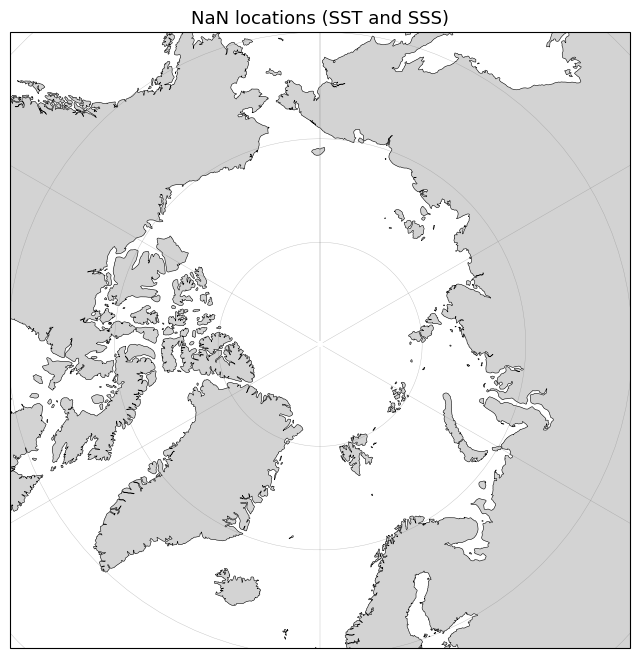

In [14]:
print(np.sum(mask))
print(len(mask))

# Create figure with Arctic projection
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

#THis should show very little profiles,
# only where there is no coverage from glorys or aviso

x_vals = ds_insitu['LONGITUDE'].values[mask]
y_vals = ds_insitu['LATITUDE'].values[mask]

# Limit to Arctic region
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Scatter colored by year 
sc = ax.scatter(
    x_vals,
    y_vals,
    #c=ds_insitu['TEMP'].isel(depth=0).values,
    s=0.5,
    c='darkblue', 
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

plt.title("NaN locations (SST and SSS)", fontsize=13)
plt.show()
#plt.savefig("Insitu_profile_salinity.png", dpi=350)

If it's only coastal, let's discard them

---
---
### plot some profiles

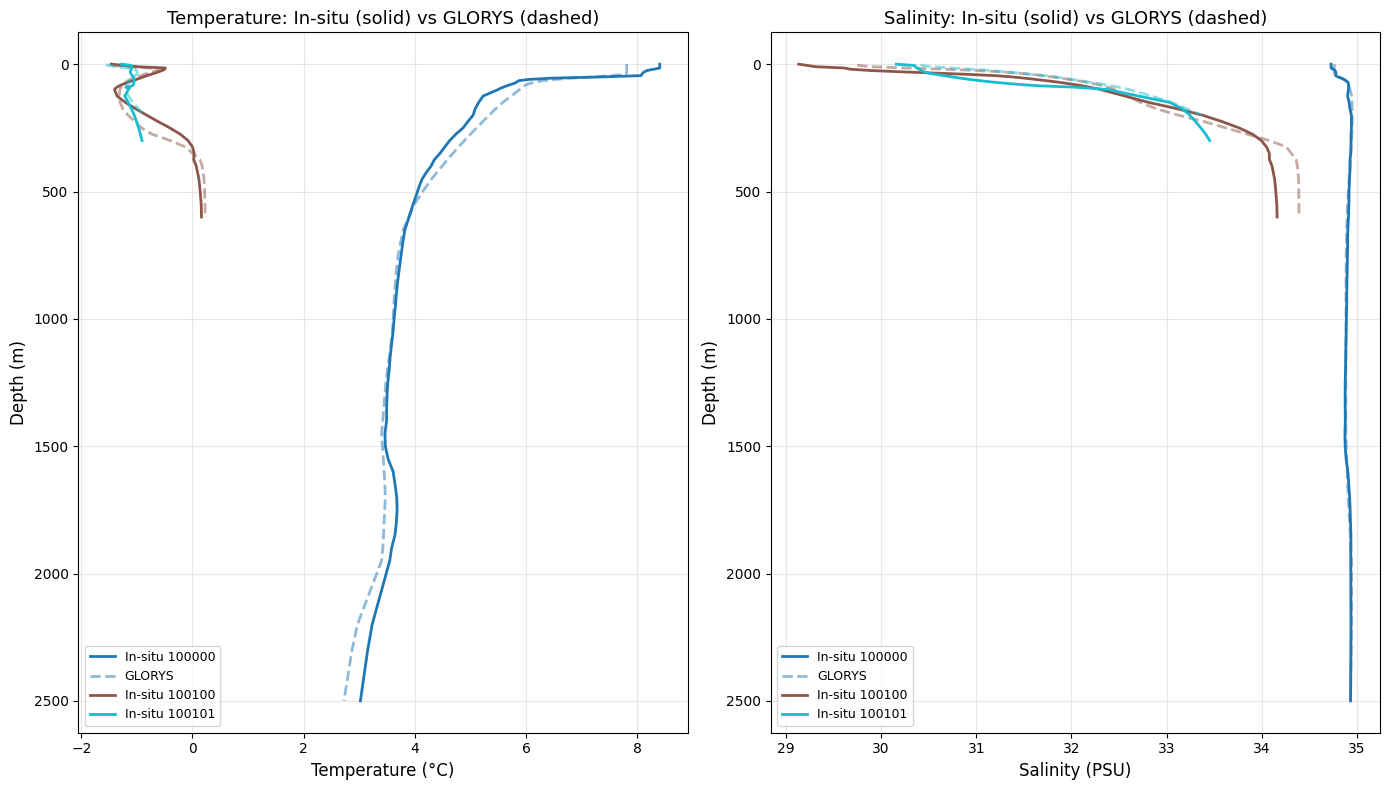

In [16]:
# Plot comparison of in-situ vs GLORYS profiles
n_profiles = 1  # Adjust number of random profiles to plot
'''
# Select random profiles
np.random.seed(42)  # For reproducibility
random_indices = np.random.choice(len(ds_insitu['profile']), size=n_profiles, replace=False)
'''
random_indices = [100000,100100,100101]
n_profiles = len(random_indices)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Color map for profiles
colors = plt.cm.tab10(np.linspace(0, 1, n_profiles))

# Plot Temperature profiles (left)
for i, prof_idx in enumerate(random_indices):
    depth = ds_insitu['depth'].values
    
    # Get in-situ Temperature
    temp_insitu = ds_insitu['TEMP'].isel(profile=prof_idx).values
    temp_glorys = ds_insitu['T_glorys_monthly'].isel(profile=prof_idx).values
    
    # Mask GLORYS data where in-situ is NaN
    valid_mask = ~np.isnan(temp_insitu)
    
    # In-situ Temperature (solid line)
    ax1.plot(temp_insitu[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, label=f'In-situ {prof_idx}')
    
    # GLORYS Temperature (transparent line, only where in-situ has data)
    glorys_label = 'GLORYS' if i == 0 else None
    ax1.plot(temp_glorys[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, alpha=0.5, linestyle='--', label=glorys_label)

ax1.invert_yaxis()
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_title('Temperature: In-situ (solid) vs GLORYS (dashed)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='best')

# Plot Salinity profiles (right)
for i, prof_idx in enumerate(random_indices):
    depth = ds_insitu['depth'].values
    
    # Get in-situ Salinity
    psal_insitu = ds_insitu['PSAL'].isel(profile=prof_idx).values
    psal_glorys = ds_insitu['S_glorys_monthly'].isel(profile=prof_idx).values
    
    # Mask GLORYS data where in-situ is NaN
    valid_mask = ~np.isnan(psal_insitu)
    
    # In-situ Salinity (solid line)
    ax2.plot(psal_insitu[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, label=f'In-situ {prof_idx}')
    
    # GLORYS Salinity (transparent line, only where in-situ has data)
    glorys_label = 'GLORYS' if i == 0 else None
    ax2.plot(psal_glorys[valid_mask], depth[valid_mask], 
             color=colors[i], linewidth=2, alpha=0.5, linestyle='--', label=glorys_label)

ax2.invert_yaxis()
ax2.set_xlabel('Salinity (PSU)', fontsize=12)
ax2.set_ylabel('Depth (m)', fontsize=12)
ax2.set_title('Salinity: In-situ (solid) vs GLORYS (dashed)', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()